In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [131]:
df=pd.read_csv('Downloads/loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [132]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [133]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [134]:
print(df.duplicated().sum())

0


In [135]:
df.columns = df.columns.str.strip()

In [136]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

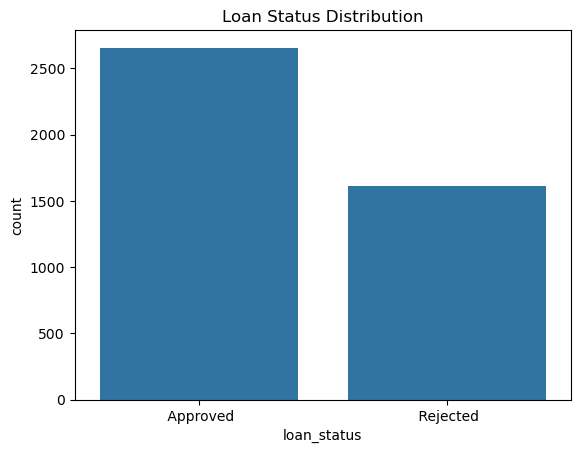

In [137]:
sns.countplot(data=df, x='loan_status')
plt.title('Loan Status Distribution')
plt.show()

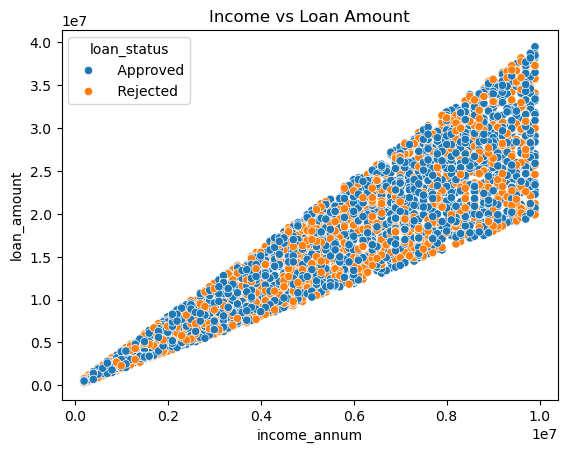

In [138]:
sns.scatterplot(
    data=df,
    x='income_annum',
    y='loan_amount',
    hue='loan_status'
)
plt.title('Income vs Loan Amount')
plt.show()

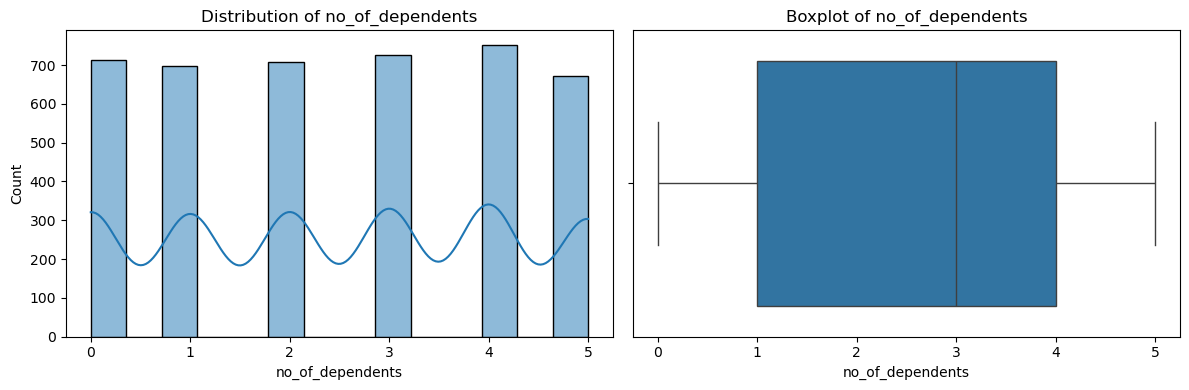

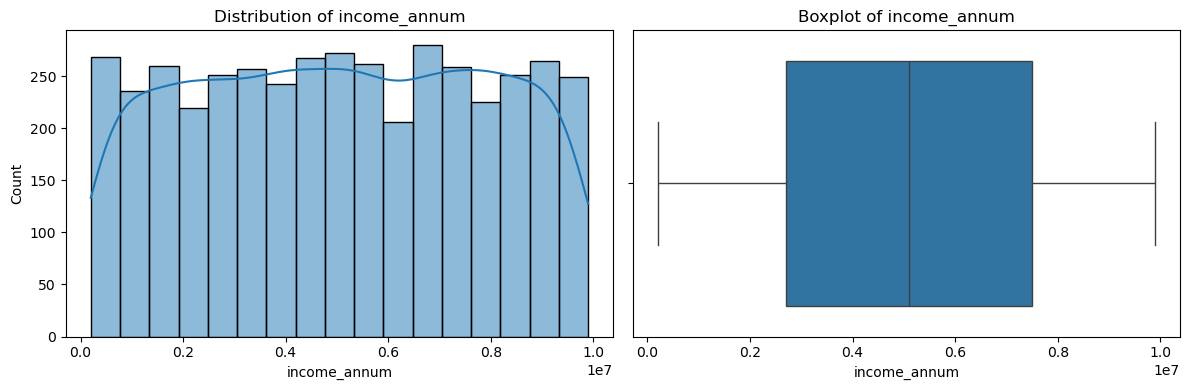

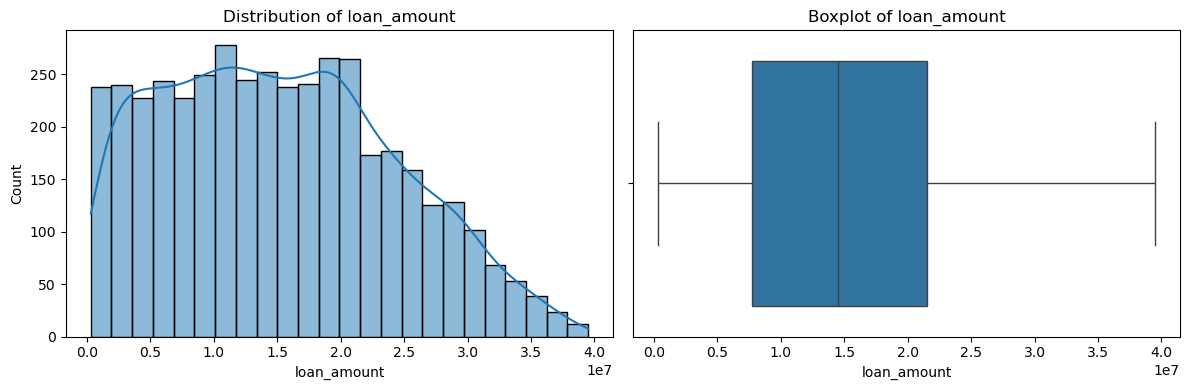

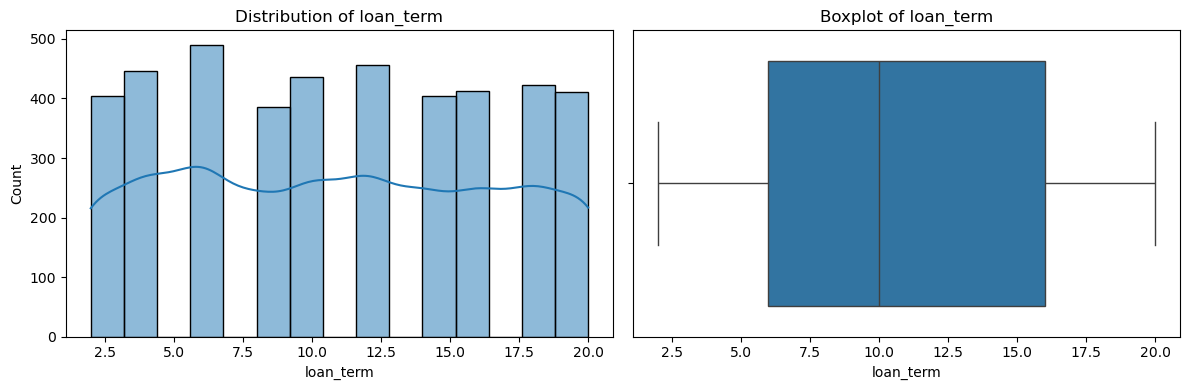

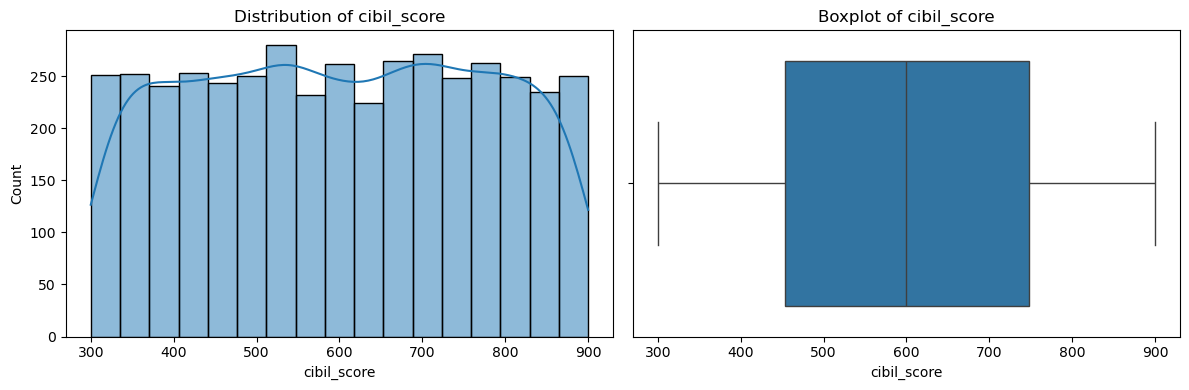

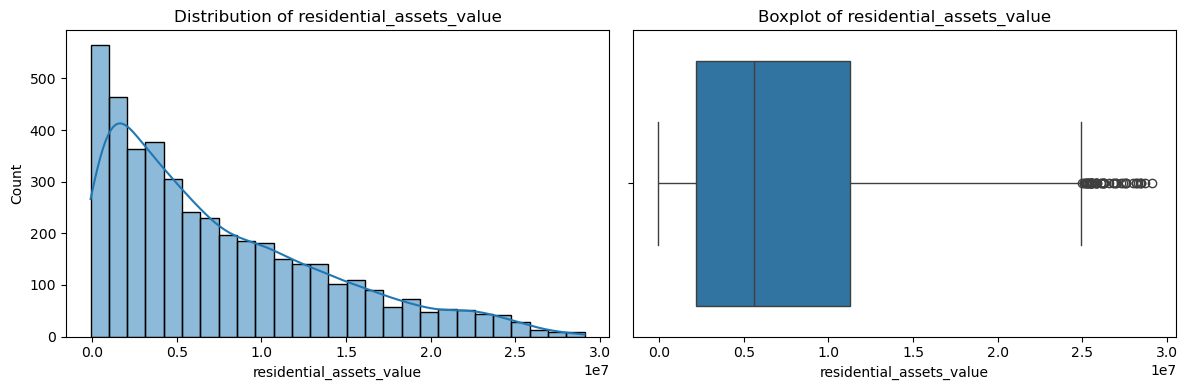

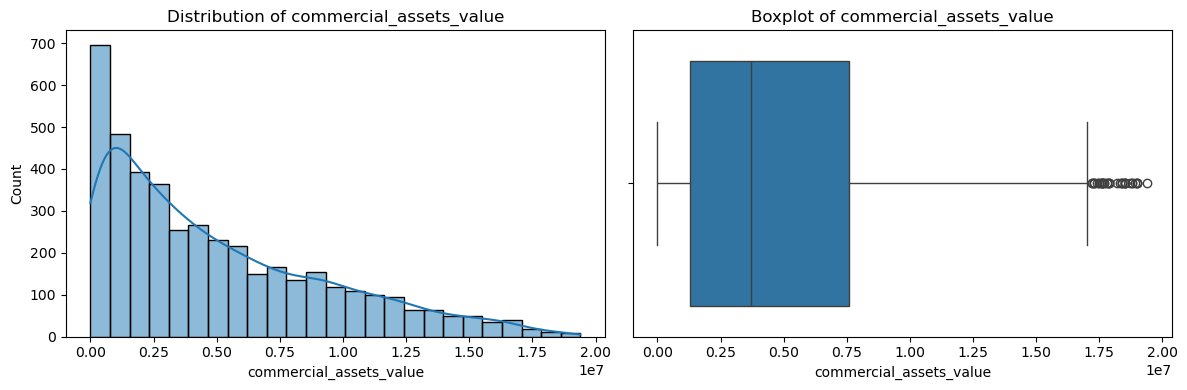

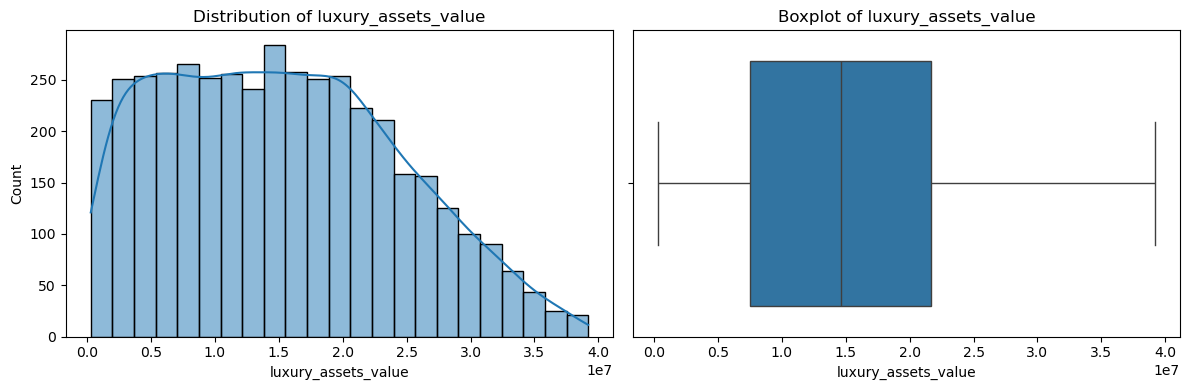

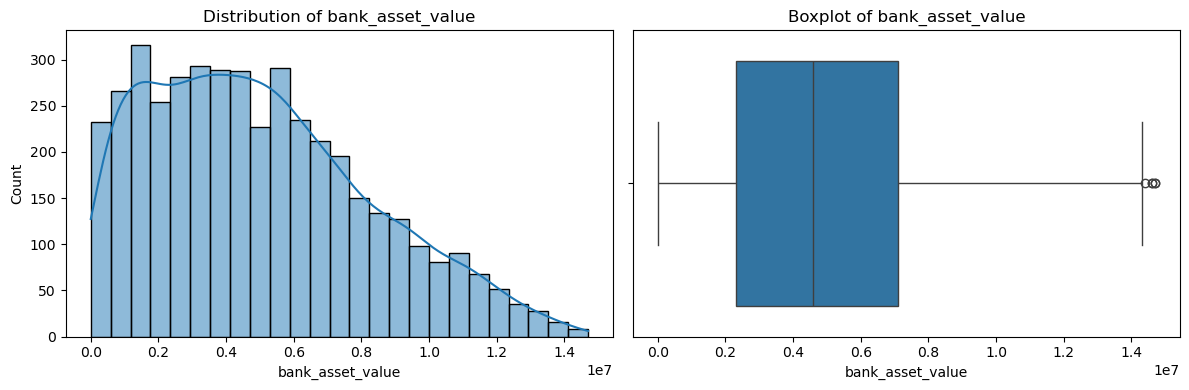

In [139]:
num_cols = [
    'no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
    'cibil_score', 'residential_assets_value', 'commercial_assets_value',
    'luxury_assets_value', 'bank_asset_value'
]

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

In [140]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [141]:
df['education'] = df['education'].str.strip()

In [142]:
df['education'] = df['education'].map({
    'Graduate': 1,
    'Not Graduate': 0
})

In [143]:
df.rename(columns={'education': 'is_Graduate'}, inplace=True)

In [144]:
df.head()

,loan_id,no_of_dependents,is_Graduate,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,0,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,1,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,1,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,0,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [145]:
df.columns

Index(['loan_id', 'no_of_dependents', 'is_Graduate', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [146]:
print(df['loan_status'].dtype)

object


In [147]:
print(df['loan_status'].unique())

[' Approved' ' Rejected']


In [148]:
df['loan_status'] = df['loan_status'].str.strip()

In [149]:
print(df['loan_status'].unique())

['Approved' 'Rejected']


In [150]:
df['loan_status'] = df['loan_status'].map({
    'Approved': 1,
    'Rejected': 0
})

In [151]:
df.head()

,loan_id,no_of_dependents,is_Graduate,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [152]:
print(df['self_employed'].unique())

[' No' ' Yes']


In [153]:
df['self_employed'] = df['self_employed'].str.strip()

In [154]:
df['self_employed'] = df['self_employed'].map({
    'Yes': 1,
    'No': 0
})

In [155]:
df.head()

,loan_id,no_of_dependents,is_Graduate,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [156]:
print(df[['is_Graduate', 'self_employed', 'loan_status']].nunique())
print(df[['is_Graduate', 'self_employed', 'loan_status']].head(10))
print(df[['is_Graduate', 'self_employed', 'loan_status']].dtypes)

is_Graduate      2
self_employed    2
loan_status      2
dtype: int64
   is_Graduate  self_employed  loan_status
0            1              0            1
1            0              1            0
2            1              0            0
3            1              0            0
4            0              1            0
5            1              1            0
6            1              0            1
7            1              1            0
8            1              1            1
9            0              0            0
is_Graduate      int64
self_employed    int64
loan_status      int64
dtype: object


In [157]:
df.drop('loan_id', axis=1, inplace=True)

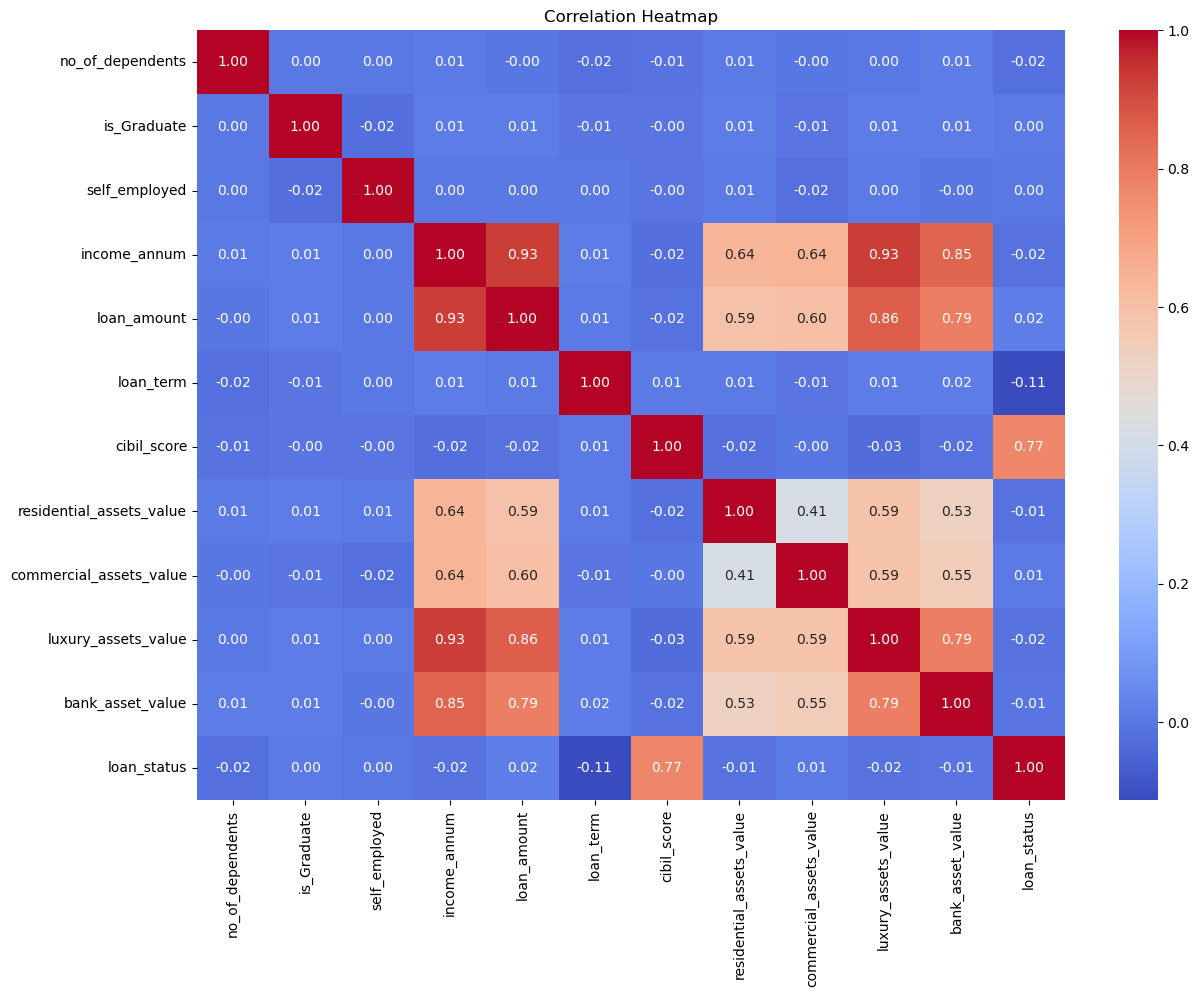

In [158]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [159]:
X=df.drop('loan_status',axis=1)
y=df['loan_status']

In [160]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [161]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [162]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9133489461358314
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       323
           1       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.90      0.91       854
weighted avg       0.91      0.91      0.91       854



In [109]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9449648711943794
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       323
           1       0.96      0.95      0.96       531

    accuracy                           0.94       854
   macro avg       0.94      0.94      0.94       854
weighted avg       0.95      0.94      0.95       854



In [163]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9812646370023419
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [164]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9800936768149883
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       323
           1       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [165]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8946135831381733
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       323
           1       0.91      0.93      0.92       531

    accuracy                           0.89       854
   macro avg       0.89      0.88      0.89       854
weighted avg       0.89      0.89      0.89       854



In [166]:
results = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'SVM': accuracy_score(y_test, y_pred_svm),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'KNN': accuracy_score(y_test, y_pred_knn)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.9133
SVM: 0.9450
Decision Tree: 0.9813
Random Forest: 0.9801
KNN: 0.8946


In [167]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_pruned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_pruned.fit(X_train, y_train)
y_pred_dt_pruned = dt_pruned.predict(X_test)

print("Pruned Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt_pruned))

Pruned Decision Tree Accuracy: 0.9742388758782201


In [168]:
print("Decision Tree Train Accuracy:", dt.score(X_train, y_train))
print("Decision Tree Test Accuracy:", dt.score(X_test, y_test))

print("Random Forest Train Accuracy:", rf.score(X_train, y_train))
print("Random Forest Test Accuracy:", rf.score(X_test, y_test))

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.9812646370023419
Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.9800936768149883


In [169]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_pruned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_pruned.fit(X_train, y_train)
y_pred_dt_pruned = dt_pruned.predict(X_test)

print("Pruned Decision Tree Train Accuracy:", dt_pruned.score(X_train, y_train))
print("Pruned Decision Tree Test Accuracy:", dt_pruned.score(X_test, y_test))
print(classification_report(y_test, y_pred_dt_pruned))

Pruned Decision Tree Train Accuracy: 0.9727672035139092
Pruned Decision Tree Test Accuracy: 0.9742388758782201
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       323
           1       0.99      0.97      0.98       531

    accuracy                           0.97       854
   macro avg       0.97      0.98      0.97       854
weighted avg       0.97      0.97      0.97       854



In [170]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Train Accuracy:", gb.score(X_train, y_train))
print("Gradient Boosting Test Accuracy:", gb.score(X_test, y_test))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Train Accuracy: 0.9967789165446559
Gradient Boosting Test Accuracy: 0.9824355971896955
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [184]:
import pickle
import os

downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "loan_approval_model.pkl")

with open(downloads_path, 'wb') as f:
    pickle.dump(gb, f)

print(f"Model saved to: {downloads_path}")

Model saved to: C:\Users\jigne\Downloads\loan_approval_model.pkl


In [176]:
import joblib
from sklearn.ensemble import GradientBoostingClassifier

# Train final model
final_model = GradientBoostingClassifier(random_state=42)
final_model.fit(X_train, y_train)

# Save the model
joblib.dump(final_model, "model.pkl")

# Gradient Boosting does not need scaling
joblib.dump(None, "scaler.pkl")

# Save only input feature columns (NO loan_status)
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, "columns.pkl")

print("model.pkl, scaler.pkl, and columns.pkl saved successfully!")

model.pkl, scaler.pkl, and columns.pkl saved successfully!


In [178]:
import os
import joblib
from sklearn.ensemble import GradientBoostingClassifier

# Train model
final_model = GradientBoostingClassifier(random_state=42)
final_model.fit(X_train, y_train)

# Download folder path
download_path = r"C:\Users\jigne\Downloads"

# Save files in Downloads
joblib.dump(final_model, os.path.join(download_path, "model.pkl"))
joblib.dump(None, os.path.join(download_path, "scaler.pkl"))
joblib.dump(X_train.columns.tolist(), os.path.join(download_path, "columns.pkl"))

print("Files saved successfully in Downloads!")

Files saved successfully in Downloads!


In [179]:
import os

print("Current working folder:")
print(os.getcwd())

Current working folder:
C:\Users\jigne


In [127]:
df.columns

Index(['no_of_dependents', 'is_Graduate', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [182]:
import os
import joblib
from sklearn.ensemble import GradientBoostingClassifier

# Train model
final_model = GradientBoostingClassifier(random_state=42)
final_model.fit(X_train, y_train)

# Download folder path
download_path = r"C:\Users\jigne\Downloads"

# Save files in Downloads
joblib.dump(final_model, os.path.join(download_path, "model.pkl"))
joblib.dump(None, os.path.join(download_path, "scaler.pkl"))
joblib.dump(X_train.columns.tolist(), os.path.join(download_path, "columns.pkl"))

print("Files saved successfully in Downloads!")

Files saved successfully in Downloads!


In [129]:
gb

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [185]:
import numpy
print(numpy.__version__)

2.2.3
